In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import product
#Astro Pryor

G = nx.DiGraph()

#Add all of the nodes and the probabilities
G.add_node("ba", ba_y=0.2, ba_n=0.8)
G.add_node("ab", ab_y=0.1, ab_n=0.9)
G.add_node("fb", fb_y=0.3, fb_n=0.7)
G.add_node("no", no_y=0.05, no_n=0.95)

G.add_node("bd",
           ba_y_bd_y=0.7, ba_n_bd_y=0.2,
           ba_y_bd_n=0.3, ba_n_bd_n=0.8)

G.add_node("nc",
           ab_y_fb_y_nc_y=0.75, ab_y_fb_n_nc_y=0.4,
           ab_n_fb_y_nc_y=0.6,  ab_n_fb_n_nc_y=0.1,
           ab_y_fb_y_nc_n=0.25, ab_y_fb_n_nc_n=0.6,
           ab_n_fb_y_nc_n=0.4,  ab_n_fb_n_nc_n=0.9)

G.add_node("bf",
           bd_y_nc_y_bf_y=0.95, bd_y_nc_n_bf_y=0.85,
           bd_n_nc_y_bf_y=0.8,  bd_n_nc_n_bf_y=0.1,
           bd_y_nc_y_bf_n=0.05, bd_y_nc_n_bf_n=0.15,
           bd_n_nc_y_bf_n=0.2,  bd_n_nc_n_bf_n=0.9)

G.add_node("l",
           bf_y_l_y=0.05, bf_n_l_y=0.9,
           bf_y_l_n=0.95, bf_n_l_n=0.1)

G.add_node("gg",
           bf_y_gg_y=0.1, bf_n_gg_y=0.95,
           bf_y_gg_n=0.9, bf_n_gg_n=0.05)

G.add_node("dl",
           no_y_dl_y=0.95, no_n_dl_y=0.3,
           no_y_dl_n=0.05, no_n_dl_n=0.7)

G.add_node("cws",
           bf_y_no_y_cws_y=0.90, bf_y_no_n_cws_y=0.90,
           bf_n_no_y_cws_y=0.30, bf_n_no_n_cws_y=0.15,
           bf_y_no_y_cws_n=0.10, bf_y_no_n_cws_n=0.10,
           bf_n_no_y_cws_n=0.70, bf_n_no_n_cws_n=0.85)
#adding the edges
G.add_edges_from([
    ("ba", "bd"),
    ("ab", "nc"),
    ("fb", "nc"),
    ("bd", "bf"),
    ("nc", "bf"),
    ("bf", "l"),
    ("bf", "gg"),
    ("no", "dl"),
    ("bf", "cws"),
    ("no", "cws")
])

#print the nodes and he edges
print("Nodes:")
print(G.nodes)
print("\nEdges:")
print(G.edges)

Nodes:
['ba', 'ab', 'fb', 'no', 'bd', 'nc', 'bf', 'l', 'gg', 'dl', 'cws']

Edges:
[('ba', 'bd'), ('ab', 'nc'), ('fb', 'nc'), ('no', 'dl'), ('no', 'cws'), ('bd', 'bf'), ('nc', 'bf'), ('bf', 'l'), ('bf', 'gg'), ('bf', 'cws')]


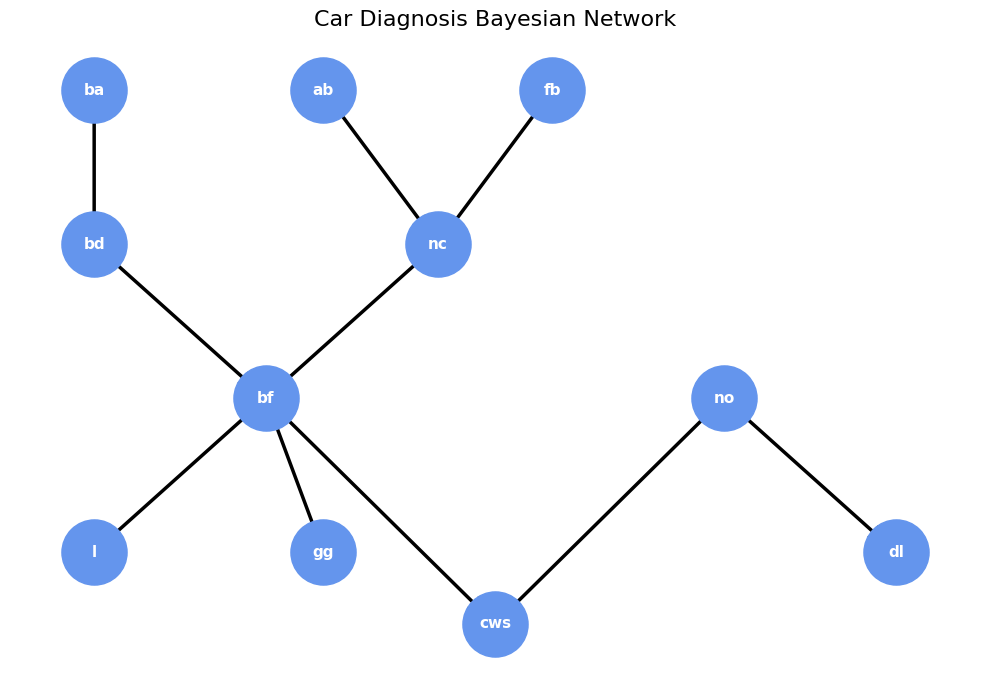

In [2]:
plt.figure(figsize=(10, 7))
#making the firgure and adding postitions so that it doesn't look all messed up anymore
pos = {
    "ba": (-3, 2),
    "ab": (-1, 2),
    "fb": (1, 2),
    "bd": (-3, 0.5),
    "nc": (0, 0.5),
    "bf": (-1.5, -1),
    "l": (-3, -2.5),
    "gg": (-1, -2.5),
    "no": (2.5, -1),
    "dl": (4, -2.5),
    "cws": (0.5, -3.2)
}

nx.draw_networkx_nodes(G, pos, node_size=2200, node_color="cornflowerblue")
nx.draw_networkx_edges(G, pos, width=2.5, arrowstyle="->", arrowsize=25)
nx.draw_networkx_labels(G, pos, font_size=11, font_color="white", font_weight="bold")

plt.title("Car Diagnosis Bayesian Network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# defining all of the probabilities
def P_ba(ba):
    return G.nodes["ba"]["ba_y"] if ba == 1 else G.nodes["ba"]["ba_n"]

def P_ab(ab):
    return G.nodes["ab"]["ab_y"] if ab == 1 else G.nodes["ab"]["ab_n"]

def P_fb(fb):
    return G.nodes["fb"]["fb_y"] if fb == 1 else G.nodes["fb"]["fb_n"]

def P_no(no):
    return G.nodes["no"]["no_y"] if no == 1 else G.nodes["no"]["no_n"]

def P_bd_given_ba(bd, ba):
    key = f"ba_{'y' if ba else 'n'}_bd_{'y' if bd else 'n'}"
    return G.nodes["bd"][key]

def P_nc_given_ab_fb(nc, ab, fb):
    key = f"ab_{'y' if ab else 'n'}_fb_{'y' if fb else 'n'}_nc_{'y' if nc else 'n'}"
    return G.nodes["nc"][key]

def P_bf_given_bd_nc(bf, bd, nc):
    key = f"bd_{'y' if bd else 'n'}_nc_{'y' if nc else 'n'}_bf_{'y' if bf else 'n'}"
    return G.nodes["bf"][key]

def P_cws_given_bf_no(cws, bf, no):
    key = f"bf_{'y' if bf else 'n'}_no_{'y' if no else 'n'}_cws_{'y' if cws else 'n'}"
    return G.nodes["cws"][key]

In [4]:
#Computing the requirement 2, so +ccsw given +fb
def compute_r2():
    total = 0.0
    for ba, ab, no, bd, nc, bf in product([0, 1], repeat=6):
        total += (
            P_ba(ba) *
            P_ab(ab) *
            P_no(no) *
            P_bd_given_ba(bd, ba) *
            P_nc_given_ab_fb(nc, ab, 1) *
            P_bf_given_bd_nc(bf, bd, nc) *
            P_cws_given_bf_no(1, bf, no)
        )
    return total

r2 = compute_r2()
print("P(+cws | +fb) =", r2)

P(+cws | +fb) = 0.6362640000000002


In [5]:
#computing requirement 3 so +csw given +ba
def compute_r3():
    total = 0.0
    for ab, fb, no, bd, nc, bf in product([0, 1], repeat=6):
        total += (
            P_ab(ab) *
            P_fb(fb) *
            P_no(no) *
            P_bd_given_ba(bd, 1) *
            P_nc_given_ab_fb(nc, ab, fb) *
            P_bf_given_bd_nc(bf, bd, nc) *
            P_cws_given_bf_no(1, bf, no)
        )
    return total

r3 = compute_r3()
print("P(+cws | +ba) =", r3)

P(+cws | +ba) = 0.6788389500000002
